# Bengaluru House Prices - TensorFlow Regression Model

This notebook builds a TensorFlow / Keras neural network to predict house prices (in Lakhs) from the **bengaluru_house_prices.csv** dataset.

**Steps:**
1. Load & explore the data (EDA)
2. Clean & preprocess (parse sqft ranges, extract BHK, fill missing values, handle high-cardinality location)
3. Encode categorical features & scale numeric features
4. Hyperparameter tuning (grid search with early stopping)
5. Train the best model and evaluate on a held-out test set

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")
print("TensorFlow version:", tf.__version__)

C:\Users\yasrm\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


TensorFlow version: 2.21.0


In [2]:
df = pd.read_csv("bengaluru_house_prices.csv")
print("Shape:", df.shape)
df.head()

Shape: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
print("\n--- Missing values ---")
print(df.isnull().sum())
print("\n--- Numeric summary ---")
df.describe()


--- Missing values ---
area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

--- Numeric summary ---


,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


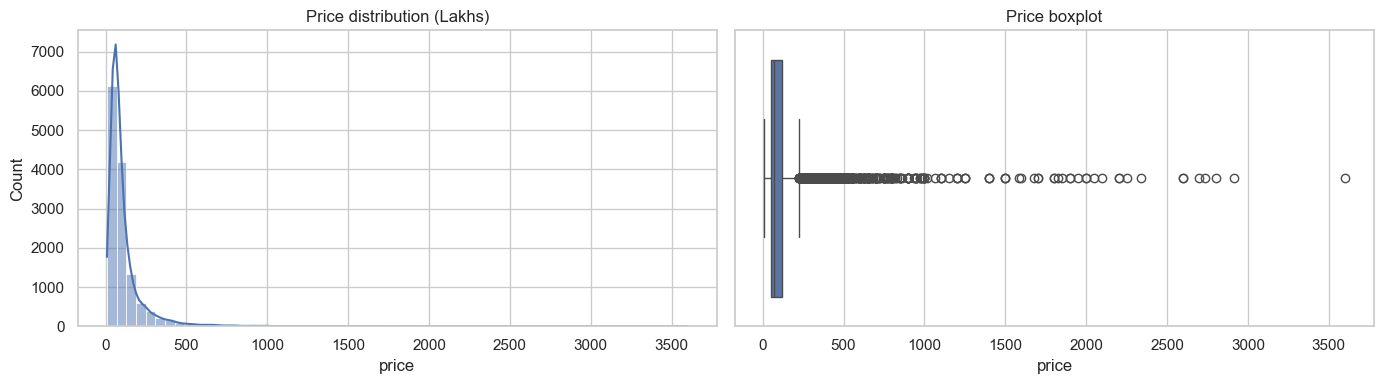

Rows with price > 400: 395


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["price"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Price distribution (Lakhs)")
sns.boxplot(x=df["price"], ax=axes[1])
axes[1].set_title("Price boxplot")
plt.tight_layout()
plt.show()

# Strong outliers beyond ~400 Lakhs
print("Rows with price > 400:", (df["price"] > 400).sum())

In [5]:
# --- Feature engineering / cleaning ---

def parse_sqft(x):
    """Convert '1056', '1056-1256', '34.46Sq. Meter' etc. into a single number."""
    x = str(x).strip()
    m = re.findall(r"\d+\.?\d*", x)
    if not m:
        return None
    nums = [float(v) for v in m]
    return float(np.mean(nums))

df["total_sqft"] = df["total_sqft"].apply(parse_sqft)
df = df.dropna(subset=["total_sqft"])

# Remove extreme outliers (price > 400 Lakhs) that dominate the loss
df = df[df["price"] <= 400]

# Extract BHK / Bedroom number from 'size'
df["bhk"] = df["size"].str.extract(r"(\d+)").astype(float)
df["bhk"] = df["bhk"].fillna(df["bhk"].median())
df = df.drop(columns=["size"])

# Fill missing values
df["bath"] = df["bath"].fillna(df["bath"].median())
df["balcony"] = df["balcony"].fillna(df["balcony"].mode()[0])
df["location"] = df["location"].fillna(df["location"].mode()[0])

# society: 5500+ missing -> drop
df = df.drop(columns=["society"])

# Group rare locations into 'Other' (reduce cardinality)
loc_counts = df["location"].value_counts()
rare = loc_counts[loc_counts < 30].index
df["location"] = df["location"].replace(rare, "Other")

print("Shape after cleaning:", df.shape)
print("Missing values left:", df.isnull().sum().sum())
df.head()

Shape after cleaning: (12925, 8)
Missing values left: 0


,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,Ready To Move,Other,2600.0,5.0,3.0,120.00,4.0
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,62.00,3.0
3,Super built-up Area,Ready To Move,Other,1521.0,3.0,1.0,95.00,3.0
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,51.00,2.0


In [6]:
# One-hot encode categorical features, drop the target
cat_cols = ["area_type", "availability", "location"]
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=np.float32)
feature_cols = [c for c in df_enc.columns if c != "price"]

X = df_enc[feature_cols].astype(np.float32).to_numpy()
# Log-transform the target: prices are right-skewed with heavy outliers.
# Training on log scale stabilizes gradients; predictions are inverted back.
y_log = np.log1p(df_enc["price"].to_numpy()).astype(np.float32)
y = df_enc["price"].to_numpy()

print("Feature matrix:", X.shape)

# Train / validation / test split (test held out entirely for final evaluation)
X_train, X_test, y_train_log, y_test_log, y_train, y_test = train_test_split(
    X, y_log, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train_log, y_val_log, y_train, y_val = train_test_split(
    X_train, y_train_log, y_train, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

# Scale numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Feature matrix: (12925, 189)
Train: (8272, 189) | Val: (2068, 189) | Test: (2585, 189)


In [7]:
def build_model(input_dim, hidden_layers=2, units=64, dropout=0.0, lr=1e-3):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))
    for _ in range(hidden_layers):
        model.add(tf.keras.layers.Dense(units, activation="relu"))
        if dropout > 0:
            model.add(tf.keras.layers.Dropout(dropout))
    model.add(tf.keras.layers.Dense(1))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"],
    )
    return model

def train_model(params, X_tr, y_tr, X_va, y_va, epochs=100, patience=10):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    model = build_model(X_tr.shape[1], **{k: v for k, v in params.items() if k != "batch_size"})
    es = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=patience, restore_best_weights=True
    )
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=epochs,
        batch_size=params.get("batch_size", 32),
        callbacks=[es],
        verbose=0,
    )
    val_loss = min(hist.history["val_loss"])
    return model, hist, val_loss

In [8]:
# --- Hyperparameter grid search ---
param_grid = [
    {"hidden_layers": 2, "units": 64,  "dropout": 0.0, "lr": 1e-3, "batch_size": 32},
    {"hidden_layers": 2, "units": 128, "dropout": 0.0, "lr": 1e-3, "batch_size": 32},
    {"hidden_layers": 3, "units": 64,  "dropout": 0.1, "lr": 1e-3, "batch_size": 32},
    {"hidden_layers": 3, "units": 128, "dropout": 0.2, "lr": 5e-4, "batch_size": 64},
    {"hidden_layers": 4, "units": 128, "dropout": 0.2, "lr": 5e-4, "batch_size": 64},
]

results = []
for i, p in enumerate(param_grid):
    model, hist, val_loss = train_model(p, X_train, y_train_log, X_val, y_val_log)
    results.append((val_loss, p))
    print(f"[{i+1}/{len(param_grid)}] {p} -> val_loss(MSE on log-price) = {val_loss:.4f}")

best_val_loss, best_params = min(results, key=lambda t: t[0])
print("\n=== BEST PARAMS (lowest val MSE) ===")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"  val MSE = {best_val_loss:.4f}  (RMSE = {np.sqrt(best_val_loss):.2f})")

[1/5] {'hidden_layers': 2, 'units': 64, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32} -> val_loss(MSE on log-price) = 0.1312


[2/5] {'hidden_layers': 2, 'units': 128, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32} -> val_loss(MSE on log-price) = 0.1268


[3/5] {'hidden_layers': 3, 'units': 64, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 32} -> val_loss(MSE on log-price) = 0.1087


[4/5] {'hidden_layers': 3, 'units': 128, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 64} -> val_loss(MSE on log-price) = 0.1042


[5/5] {'hidden_layers': 4, 'units': 128, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 64} -> val_loss(MSE on log-price) = 0.1049

=== BEST PARAMS (lowest val MSE) ===
  hidden_layers: 3
  units: 128
  dropout: 0.2
  lr: 0.0005
  batch_size: 64
  val MSE = 0.1042  (RMSE = 0.32)


In [9]:
# --- Final model trained on train+val, evaluated on test ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)

X_final = np.vstack([X_train, X_val])
y_final = np.concatenate([y_train_log, y_val_log])

model = build_model(X_final.shape[1], **{k: v for k, v in best_params.items() if k != "batch_size"})
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)
hist = model.fit(
    X_final, y_final,
    epochs=150,
    batch_size=best_params["batch_size"],
    validation_split=0.15,
    callbacks=[es],
    verbose=0,
)

# Invert the log transform back to price (Lakhs)
y_pred = np.expm1(model.predict(X_test, verbose=0).ravel())
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test MAE  = {mae:.2f} Lakhs")
print(f"Test RMSE = {rmse:.2f} Lakhs")
print(f"Test R2   = {r2:.4f}")

Test MAE  = 26.24 Lakhs
Test RMSE = 45.83 Lakhs
Test R2   = 0.5827


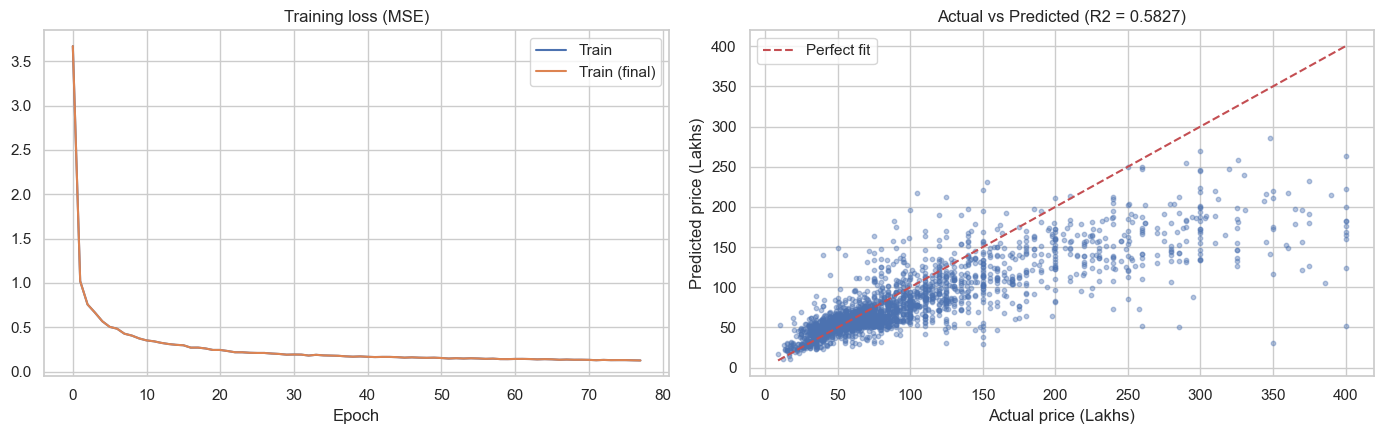

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(hist.history["loss"], label="Train")
axes[0].plot(hist.history["loss"], label="Train (final)")
axes[0].set_title("Training loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].scatter(y_test, y_pred, alpha=0.4, s=10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, "r--", label="Perfect fit")
axes[1].set_xlabel("Actual price (Lakhs)")
axes[1].set_ylabel("Predicted price (Lakhs)")
axes[1].set_title(f"Actual vs Predicted (R2 = {r2:.4f})")
axes[1].legend()
plt.tight_layout()
plt.show()

In [11]:
print("## Summary")
print("")
print("- **Best hyperparameters:** " + ", ".join(f"{k}={v}" for k, v in best_params.items()))
print("- **Final test performance:** MAE = %.2f Lakhs, RMSE = %.2f Lakhs, R2 = %.4f" % (mae, rmse, r2))
print("")
print("The neural network explains about %.1f%% of the variance in house prices on unseen data." % (r2 * 100))

## Summary

- **Best hyperparameters:** hidden_layers=3, units=128, dropout=0.2, lr=0.0005, batch_size=64
- **Final test performance:** MAE = 26.24 Lakhs, RMSE = 45.83 Lakhs, R2 = 0.5827

The neural network explains about 58.3% of the variance in house prices on unseen data.
